# Grover算法流程概述

## 1.初始化步骤
首先我们需要创造各种组合的**均匀**叠加态：

In [ ]:
for i in range(num_inputs):
    qc.h(qr[i])

我们还需要把黑箱函数的输出比特设置成$\left|-\right>$，代码如下

In [ ]:
qc.x(qr[num_registers - 1])
qc.h(qr[num_registers - 1])

注意到$$HX\left|0\right>=H\left|1\right>=\left|-\right>$$

## 2.checker和mover步骤
为了突出其实际意义，我们这里将黑箱和扩散分别叫作checker和mover。于是Grover算法的核心步骤可以如下写出：

In [ ]:
for _ in range(iterations):
    checker(qr, qc)
    mover(qr, qc, num_inputs)

## 3.测量步骤
在算法的最后，我们需要测量量子比特得到最终概率：

In [ ]:
for i in range(num_inputs):
    qc.measure(qr[i], cr[i])

# 3SAT量子版本

## 适用于两个量子比特和三个量子比特的量子AND门

In [1]:
def qAND2(qr, qc, x, y, t1):
    qc.ccx(qr[x], qr[y], qr[t1])
    
    qc.barrier(qr)
    return t1

In [2]:
def qAND3(qr, qc, x, y, z, t1, t2):
    qc.ccx(qr[x], qr[y], qr[t1])
    qc.ccx(qr[z], qr[t1], qr[t2])
    
    qc.barrier(qr)
    return t2

注意到，AND门是其自身的反转门，所以只需要连续使用两次AND门，量子寄存器就会回到AND门处理之前的状态

## 适用于两个量子比特和三个量子比特的量子OR门

In [3]:
def qOR2(qr, qc, x, y, t1):
    qc.x(qr[x])
    qc.x(qr[y])
    qc.x(qr[t1])
    qc.ccx(qr[x], qr[y], qr[t1])
    qc.x(qr[x])
    qc.x(qr[y])
    
    qc.barrier(qr)
    return t1

In [4]:
def qOR3(qr, qc, x, y, z, t1, t2):
    qc.x(qr[x])
    qc.x(qr[y])
    qc.x(qr[t1])
    qc.ccx(qr[x], qr[y], qr[t1])
    qc.x(qr[x])
    qc.x(qr[y])
    
    qc.x(qr[z])
    qc.x(qr[t1])
    qc.x(qr[t2])
    qc.ccx(qr[z], qr[t1], qr[t2])
    qc.x(qr[z])
    qc.x(qr[t1])
    
    qc.barrier(qr)
    return t2

可以看到，OR门是不对称的，因此需要另外写出它的反转门

In [5]:
def qOR2_rev(qr, qc, x, y, t1):
    qc.x(qr[x])
    qc.x(qr[y])
    qc.ccx(qr[x], qr[y], qr[t1])
    qc.x(qr[t1])
    qc.x(qr[x])
    qc.x(qr[y])
    
    qc.barrier(qr)
    return t1

In [6]:
def qOR3_rev(qr, qc, x, y, z, t1, t2):
    qc.x(qr[z])
    qc.x(qr[t1])
    qc.ccx(qr[z], qr[t1], qr[t2])
    qc.x(qr[t2])
    qc.x(qr[z])
    qc.x(qr[t1])
    
    qc.x(qr[x])
    qc.x(qr[y])
    qc.ccx(qr[x], qr[y], qr[t1])
    qc.x(qr[t1])
    qc.x(qr[x])
    qc.x(qr[y])
    
    qc.barrier(qr)
    return t2

## 单元测试

In [7]:
from qiskit import *
import itertools
def run(qc):
    backend = BasicAer.get_backend('qasm_simulator')
    job_exp = execute(qc, backend = backend)
    result  = job_exp.result()
    final   = result.get_counts(qc)
    result_in_order = list(final.keys())[0][::-1]
    return result_in_order

In [8]:
def setup_input(qr,qc,a,b,c,d=None): #量子电路中初始态即为0，若欲设置成1反转即可
    if a:
        qc.x(qr[0])
    if b:
        qc.x(qr[1])
    if c:
        qc.x(qr[2])
    if d:
        qc.x(qr[4])

In [9]:
def test_qAND2_qOR2(f, f_rev):
    print("输入\t","执行\t","反转")
    print("abc\t","a'b'c'\t","a''b''c''")
    for combo in itertools.product([0,1], repeat=3):
        # 执行
        qr = QuantumRegister(3)
        cr = ClassicalRegister(3)
        qc = QuantumCircuit(qr,cr)
        setup_input(qr,qc,combo[0],combo[1],combo[2])
        # False True False -> 是否翻转
        # 010 ->量子态本身
        f(qr,qc,0,1,2)
        for i in range(3):
            qc.measure(qr[i],cr[i])
        forward_result=run(qc)
        # 执行并反转
        qr = QuantumRegister(3)
        cr = ClassicalRegister(3)
        qc = QuantumCircuit(qr,cr)
        setup_input(qr,qc,combo[0],combo[1],combo[2])
        f(qr,qc,0,1,2)
        f_rev(qr,qc,0,1,2)
        for i in range(3):
            qc.measure(qr[i],cr[i])
        reverse_result=run(qc)
        print('%d%d%d\t%s\t%s'%(combo[0],combo[1],combo[2],forward_result,reverse_result))

In [10]:
def test_qAND3_qOR3(f,f_rev):
    print("输入\t","执行\t","反转")
    print("abcd\t","a'b'c'd'\t","a''b''c''d''")
    for combo in itertools.product([0,1], repeat=4):
        # 执行
        qr = QuantumRegister(5)
        cr = ClassicalRegister(5)
        qc = QuantumCircuit(qr,cr)
        setup_input(qr,qc,combo[0],combo[1],combo[2],combo[3])
        f(qr,qc,0,1,2,3,4)
        for i in range(5):
            qc.measure(qr[i],cr[i])
        forward_result=run(qc)
        # 执行并反转
        qr = QuantumRegister(5)
        cr = ClassicalRegister(5)
        qc = QuantumCircuit(qr,cr)
        setup_input(qr,qc,combo[0],combo[1],combo[2],combo[3])
        f(qr,qc,0,1,2,3,4)
        f_rev(qr,qc,0,1,2,3,4)
        for i in range(5):
            qc.measure(qr[i],cr[i])
        reverse_result=run(qc)
        
        forward_result=forward_result[0:3]+forward_result[4]
        reverse_result=reverse_result[0:3]+reverse_result[4]
 
        print('%d%d%d%d\t%s\t%s'%(combo[0],combo[1],combo[2],combo[3],forward_result,reverse_result))

In [11]:
print("Testing two qubit quantum AND")
test_qAND2_qOR2(qAND2, qAND2)
print()
 
print("Testing two qubit quantum OR")
test_qAND2_qOR2(qOR2, qOR2_rev)
print()
 
print("Testing three qubit quantum AND")
test_qAND3_qOR3(qAND3, qAND3)
print()
 
print("Testing three qubit quantum OR")
test_qAND3_qOR3(qOR3, qOR3_rev)

Testing two qubit quantum AND
输入	 执行	 反转
abc	 a'b'c'	 a''b''c''
000	000	000
001	001	001
010	010	010
011	011	011
100	100	100
101	101	101
110	111	110
111	110	111

Testing two qubit quantum OR
输入	 执行	 反转
abc	 a'b'c'	 a''b''c''
000	000	000
001	001	001
010	011	010
011	010	011
100	101	100
101	100	101
110	111	110
111	110	111

Testing three qubit quantum AND
输入	 执行	 反转
abcd	 a'b'c'd'	 a''b''c''d''
0000	0000	0000
0001	0001	0001
0010	0010	0010
0011	0011	0011
0100	0100	0100
0101	0101	0101
0110	0110	0110
0111	0111	0111
1000	1000	1000
1001	1001	1001
1010	1010	1010
1011	1011	1011
1100	1100	1100
1101	1101	1101
1110	1111	1111
1111	1110	1110

Testing three qubit quantum OR
输入	 执行	 反转
abcd	 a'b'c'd'	 a''b''c''d''
0000	0000	0000
0001	0001	0001
0010	0011	0010
0011	0010	0011
0100	0101	0100
0101	0100	0101
0110	0111	0110
0111	0110	0111
1000	1001	1000
1001	1000	1001
1010	1011	1010
1011	1010	1011
1100	1101	1100
1101	1100	1101
1110	1111	1110
1111	1110	1111


# 3SAT的Grover算法解决方案

## 黑箱函数的实现

In [12]:
def _3sat_classical(a, b, c):
    return int((a or b or not c) and (a or b or c) and (a or not b or c) 
               and (a or not b or not c) and (not a or b or not c)  and (not a or b or c) and (not a or not b or not c) )

检查各种输入组合，以免我们的布尔表达式构建错误：

In [13]:
for combo in itertools.product([0,1],repeat=3):
    print(combo,'->',_3sat_classical(combo[0],combo[1], combo[2]))

(0, 0, 0) -> 0
(0, 0, 1) -> 0
(0, 1, 0) -> 0
(0, 1, 1) -> 0
(1, 0, 0) -> 0
(1, 0, 1) -> 0
(1, 1, 0) -> 1
(1, 1, 1) -> 0


## 量子3SAT实现逻辑
### 1.编写“逻辑设置或逻辑清除函数”

In [14]:
def setup_or_teardown_logic(qr,qc,is_a,is_b,is_c): 
    """    
    is_a,is_b,and is_c: False indicates the variable should be negated, True left as is.
    Negation is done with the X gate.
    """    
    if not is_a:
        qc.x(qr[0])
    if not is_b:
        qc.x(qr[1])
    if not is_c:
        qc.x(qr[2])

### 2.逐一计算子句组装后并反转逻辑

In [15]:
def _3sat(qr, qc, reverse=True, full_reverse=False):
    # w,x,y对应寄存器0,1,2号. 
    # 其余均为临时/结果寄存器
    # 大体流程:
    # 1. 设置逻辑
    # 2. 执行计算
    # 3. 恢复状态
 
    # (a or b or not c)
    setup_or_teardown_logic(qr,qc,True,True,False)
    first_clause=qOR3(qr,qc,0,1,2,3,4)
    setup_or_teardown_logic(qr,qc,True,True,False)
 
    # (a or b or c) 
    setup_or_teardown_logic(qr,qc,True,True,True)
    second_clause=qOR3(qr,qc,0,1,2,5,6)
    setup_or_teardown_logic(qr,qc,True,True,True)
 
    # (a or not b or c)
    setup_or_teardown_logic(qr,qc,True,False,True)
    third_clause=qOR3(qr,qc,0,1,2,7,8)
    setup_or_teardown_logic(qr,qc,True,False,True)
 
    # (a or not b or not c)
    setup_or_teardown_logic(qr,qc,True,False,False)
    fourth_clause=qOR3(qr,qc,0,1,2,9,10)
    setup_or_teardown_logic(qr,qc,True,False,False)
 
    # (not a or b or not c) 
    setup_or_teardown_logic(qr,qc,False,True,False)
    fifth_clause=qOR3(qr,qc,0,1,2,11,12)
    setup_or_teardown_logic(qr,qc,False,True,False)
 
    # (not a or b or c)
    setup_or_teardown_logic(qr,qc,False,True,True)
    sixth_clause=qOR3(qr,qc,0,1,2,13,14)
    setup_or_teardown_logic(qr,qc,False,True,True)
 
    # (not a or not b or not c) 
    setup_or_teardown_logic(qr,qc,False,False,False)
    seventh_clause=qOR3(qr,qc,0,1,2,15,16)
    setup_or_teardown_logic(qr,qc,False,False,False)
 
 
    # Let's whittle down
    intermediate_and_pair1=qAND2(qr,qc,first_clause,second_clause,17)
    intermediate_and_pair2=qAND2(qr,qc,third_clause,fourth_clause,18)
    intermediate_and_pair3=qAND2(qr,qc,fifth_clause,sixth_clause,19)
 
    # Now whittling down further
    intermediate_and_pair_12=qAND2(qr,qc,intermediate_and_pair1,intermediate_and_pair2,20)
    intermediate_and_pair_34=qAND2(qr,qc,intermediate_and_pair3,seventh_clause,21)
 
    # Now whittling down to 1 result
    final_result_and_pair_1234=qAND2(qr,qc,intermediate_and_pair_12,intermediate_and_pair_34,22)
    
    if reverse:
        if full_reverse:
            final_result_and_pair_1234=qAND2(qr,qc,intermediate_and_pair_12,intermediate_and_pair_34,22)
        intermediate_and_pair_34=qAND2(qr,qc,intermediate_and_pair3,seventh_clause,21)
        intermediate_and_pair_12=qAND2(qr,qc,intermediate_and_pair1,intermediate_and_pair2,20)
        intermediate_and_pair3=qAND2(qr,qc,fifth_clause,sixth_clause,19)
        intermediate_and_pair2=qAND2(qr,qc,third_clause,fourth_clause,18)
        intermediate_and_pair1=qAND2(qr,qc,first_clause,second_clause,17)
        # (not a or not b or not c) 
        setup_or_teardown_logic(qr,qc,False,False,False)
        seventh_clause=qOR3_rev(qr,qc,0,1,2,15,16) 
        setup_or_teardown_logic(qr,qc,False,False,False)
        # (not a or b or c)
        setup_or_teardown_logic(qr,qc,False,True,True)
        sixth_clause=qOR3_rev(qr,qc,0,1,2,13,14)
        setup_or_teardown_logic(qr,qc,False,True,True)
        # (not a or b or not c) 
        setup_or_teardown_logic(qr,qc,False,True,False)
        fifth_clause=qOR3_rev(qr,qc,0,1,2,11,12)
        setup_or_teardown_logic(qr,qc,False,True,False)
        # (a or not b or not c)
        setup_or_teardown_logic(qr,qc,True,False,False)
        fourth_clause=qOR3_rev(qr,qc,0,1,2,9,10)
        setup_or_teardown_logic(qr,qc,True,False,False)
        # (a or not b or c)
        setup_or_teardown_logic(qr,qc,True,False,True)
        third_clause=qOR3_rev(qr,qc,0,1,2,7,8)
        setup_or_teardown_logic(qr,qc,True,False,True)
        # (a or b or c) 
        setup_or_teardown_logic(qr,qc,True,True,True)
        second_clause=qOR3_rev(qr,qc,0,1,2,5,6)
        setup_or_teardown_logic(qr,qc,True,True,True)
        # (a or b or not c)
        setup_or_teardown_logic(qr,qc,True,True,False)
        first_clause=qOR3_rev(qr,qc,0,1,2,3,4)
        setup_or_teardown_logic(qr,qc,True,True,False)

### 3.单元测试

In [16]:
import time
from qiskit.tools.visualization import plot_histogram
def try_input_combination(input_combination,shots=1,reverse=False,full_reverse=True):
    
    backend  = BasicAer.get_backend('qasm_simulator') # remote simulator
    qr = QuantumRegister(23)
    cr = ClassicalRegister(23)
    qc = QuantumCircuit(qr,cr)
    # setting up the input
    for i in range(3):
        if input_combination[i]:
            qc.x(qr[i])
    # calling the function on that input
    _3sat(qr,qc,reverse=reverse,full_reverse=full_reverse)
    # measuring every qubit as we will want to verify reversibility 
    for i in range(23):
        qc.measure(qr[i],cr[i])
 
    # Executing the job on IBM QX
    job_exp = execute(qc, backend=backend,shots=shots)
    result = job_exp.result()
    final=result.get_counts(qc)
    if not len(final)==1:
        print(input_combination,final)
    else:
        # note that due to IBM's choice the result returned is in opposite order with last register coming first 
        # and the first register coming last. For clarity we reverse the output so the first register is first
        # and the last register is last.

        result_in_order=list(final.keys())[0][::-1]
        print(input_combination,'->',result_in_order[-1],'(measured bits: '+result_in_order+')')

In [17]:
for combo in itertools.product([0,1],repeat=3):
    try_input_combination(combo)

(0, 0, 0) -> 0 (measured bits: 00001001111111111011010)
(0, 0, 1) -> 0 (measured bits: 00100011111111111011010)
(0, 1, 0) -> 0 (measured bits: 01011110001111111101010)
(0, 1, 1) -> 0 (measured bits: 01111110100111111101010)
(1, 0, 0) -> 0 (measured bits: 10011111111010011110100)
(1, 0, 1) -> 0 (measured bits: 10111111111000111110100)
(1, 1, 0) -> 1 (measured bits: 11011111111111101111111)
(1, 1, 1) -> 0 (measured bits: 11111111111111100111100)


In [18]:
for combo in itertools.product([0,1],repeat=3):
    try_input_combination(combo, reverse=True, full_reverse=True)

(0, 0, 0) -> 0 (measured bits: 00000000000000000000000)
(0, 0, 1) -> 0 (measured bits: 00100000000000000000000)
(0, 1, 0) -> 0 (measured bits: 01000000000000000000000)
(0, 1, 1) -> 0 (measured bits: 01100000000000000000000)
(1, 0, 0) -> 0 (measured bits: 10000000000000000000000)
(1, 0, 1) -> 0 (measured bits: 10100000000000000000000)
(1, 1, 0) -> 0 (measured bits: 11000000000000000000000)
(1, 1, 1) -> 0 (measured bits: 11100000000000000000000)


In [19]:
for combo in itertools.product([0,1],repeat=3):
    try_input_combination(combo,reverse=True,full_reverse=False)

(0, 0, 0) -> 0 (measured bits: 00000000000000000000000)
(0, 0, 1) -> 0 (measured bits: 00100000000000000000000)
(0, 1, 0) -> 0 (measured bits: 01000000000000000000000)
(0, 1, 1) -> 0 (measured bits: 01100000000000000000000)
(1, 0, 0) -> 0 (measured bits: 10000000000000000000000)
(1, 0, 1) -> 0 (measured bits: 10100000000000000000000)
(1, 1, 0) -> 1 (measured bits: 11000000000000000000001)
(1, 1, 1) -> 0 (measured bits: 11100000000000000000000)


## 扩散函数实现

In [20]:
def control_Z(qr,qc,num_inputs):
    if num_inputs not in [2,3]:
        raise Exception("currently only supports 2 or 3 inputs")
    if num_inputs==2:
        qc.h(qr[1])
        qc.cx(qr[0],qr[1])
        qc.h(qr[1])
    elif num_inputs==3:
        qc.h(qr[2])
        qc.ccx(qr[0],qr[1],qr[2])    
        qc.h(qr[2])
    
def mover(qr,qc,num_inputs):
    if num_inputs not in [2,3]:
        raise Exception("currently only supports 2 or 3 inputs")
    for i in range(num_inputs):
        qc.h(qr[i])
    for i in range(num_inputs):
        qc.x(qr[i]) 
    control_Z(qr,qc,num_inputs)
    for i in range(num_inputs):
        qc.x(qr[i])
    for i in range(num_inputs):
        qc.h(qr[i])

## 运行Grover算法

In [25]:
def grovers_algorithm(checker,num_inputs,num_registers,num_iterations=None):
    if num_iterations == None:
        from math import floor,sqrt
        iterations=floor(sqrt(2**num_inputs))
    else:
        iterations=num_iterations
    print("Running Grover's algorithm for %d iterations"%iterations)
    qr = QuantumRegister(num_registers)
    cr = ClassicalRegister(num_registers)
    qc = QuantumCircuit(qr,cr)
    # Configuring the input
    for i in range(num_inputs):
        qc.h(qr[i])
    # Setting up the output of the checker function
    qc.x(qr[num_registers-1])
    qc.h(qr[num_registers-1])
    
    # Do the Grovers steps
    for it in range(iterations):
        checker(qr,qc)
        mover(qr,qc,num_inputs)
    # Measure the inputs
    for j in range(num_inputs):
        qc.measure(qr[j], cr[j])
    return cr,qr,qc
 
def run_3sat_mystery_grover(num_iterations=None,backend=None):
    if not backend:
        backend = BasicAer.get_backend('qasm_simulator')
    import time
    from qiskit.tools.visualization import plot_histogram
    shots=512
    cr,qr,qc = grovers_algorithm(_3sat,3,23,num_iterations=num_iterations)
    job_exp = execute(qc, backend=backend,shots=shots)
    result = job_exp.result()
    final = result.get_counts(qc)
    print(final)
    return final

Running Grover's algorithm for 3 iterations
{'00000000000000000000011': 182, '00000000000000000000111': 48, '00000000000000000000000': 46, '00000000000000000000101': 44, '00000000000000000000110': 49, '00000000000000000000100': 52, '00000000000000000000010': 48, '00000000000000000000001': 43}


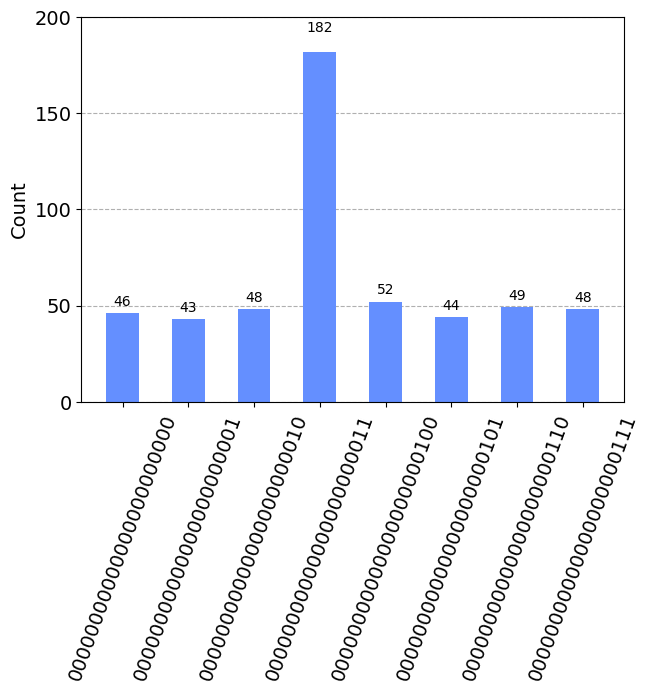

In [26]:
final=run_3sat_mystery_grover(num_iterations=3)
plot_histogram(final)